# Arch Technologies — Machine Learning Internship (Month 2)
## Task 4: Iris Flower Classification

This notebook implements the assigned Iris flower classification task using the supplied `IRIS.csv` dataset.

**Workflow:** data loading → inspection → preprocessing → stratified train/test split → Random Forest classification → evaluation → confusion matrix → feature importance.


## Libraries & Dataset Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [4]:
# Locate the supplied Iris dataset
df = pd.read_csv('IRIS.csv')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Data Inspection

In [5]:
print("Shape:", df.shape)
display(df.head())
display(df.info())


Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

In [6]:
# Check missing values and class distribution
print("Missing values:")
display(df.isna().sum())

print("\nClass distribution:")
display(df["species"].value_counts())


Missing values:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


Class distribution:


species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
# Separate predictors and target
X = df.drop(columns=["species"])
y = df["species"]

print("Predictor columns:", X.columns.tolist())
print("Classes:", sorted(y.unique()))


Predictor columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [8]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 120
Testing rows: 30


## Applying Model

In [9]:
# Random Forest classification pipeline
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=180,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
predictions = model.predict(X_test)


In [10]:
# Evaluate the classifier
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average="weighted")
recall = recall_score(y_test, predictions, average="weighted")
f1 = f1_score(y_test, predictions, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, predictions))


Accuracy : 0.9000
Precision: 0.9024
Recall   : 0.9000
F1-score : 0.8997

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



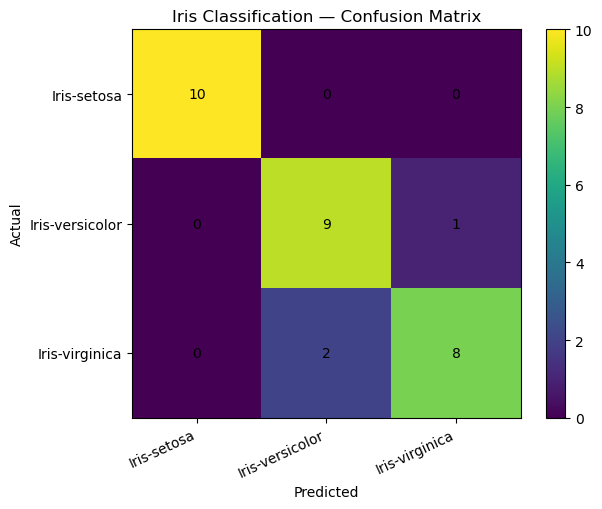

In [11]:
# Confusion matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, predictions, labels=labels)

plt.figure(figsize=(6.5, 5.2))
plt.imshow(cm, interpolation="nearest")
plt.title("Iris Classification — Confusion Matrix")
plt.colorbar()

ticks = np.arange(len(labels))
plt.xticks(ticks, labels, rotation=25, ha="right")
plt.yticks(ticks, labels)

for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        plt.text(c, r, str(cm[r, c]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


petal_length    0.459491
petal_width     0.405837
sepal_length    0.117260
sepal_width     0.017413
dtype: float64

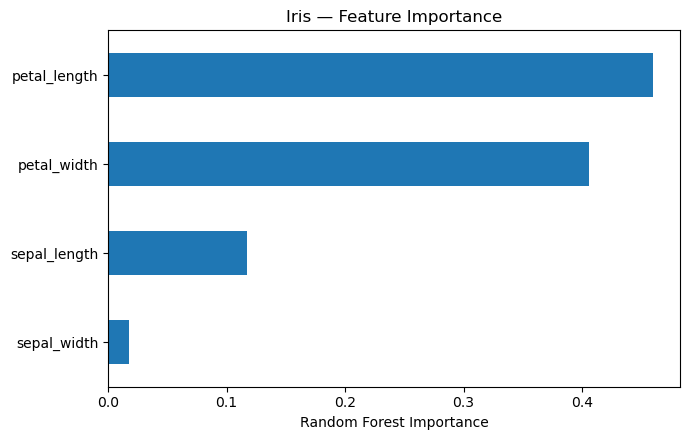

In [12]:
# Feature importance
rf = model.named_steps["model"]

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(feature_importance)

plt.figure(figsize=(7, 4.5))
feature_importance.sort_values().plot(kind="barh")
plt.xlabel("Random Forest Importance")
plt.title("Iris — Feature Importance")
plt.tight_layout()
plt.show()
